# Sea ice volume annual climatology

In [1]:
import intake
from access_nri_intake.source.builders import AccessOm2Builder
import matplotlib.pyplot as plt
from dask.distributed import Client
import datetime as dt
import numpy as np
import xarray as xr
import os
import copy

In [2]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 126.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38021,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40555,Total threads: 1
Dashboard: /proxy/33415/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:41345,


In [3]:
# add experiments to my own intake:
datapaths = {
    'Control': '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath',
    'Basal': '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb',
    'Basal_LH': '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb',
    'Basal_LH_Brine': '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine',
}

In [4]:
%%time
for n, p in datapaths.items():
    if not os.path.isfile(n+'.json'):
        AccessOm2Builder(path=p).build().save(name=n, description=n)

CPU times: user 5.57 ms, sys: 1.72 ms, total: 7.28 ms
Wall time: 4.76 ms


In [5]:
catalogs = dict()
for n in datapaths:
    catalogs[n] = intake.open_esm_datastore(
        n+".json",
        columns_with_iterables=["variable",
                                "variable_long_name",
                                "variable_standard_name",
                                "variable_cell_methods",
                                "variable_units"] # This is important
    )

In [6]:
start_time='1907-01-01'
end_time='1910-01-01'

In [7]:
# shelf masking:
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf_mask = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf_mask[np.where(shelf_mask!=0)] = np.nan
shelf_mask = shelf_mask+1
shelf_mask = xr.DataArray(shelf_mask, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])

In [8]:
%%time
vol = dict()
vol_shelf = dict()
for n, cat in catalogs.items():
    hi = cat.search(variable="hi_m")
    hi = hi.to_dask(
        xarray_combine_by_coords_kwargs={
            'compat' : 'override',
            'data_vars': 'minimal',
            'coords': 'minimal'},
        xarray_kwargs = {"use_cftime" : True,
                         "decode_coords": False,
                         "decode_timedelta" : False,
                         "chunks": "auto"}
        )["hi_m"]

    # Applying time correction
    hi['time'] = hi.time - dt.timedelta(hours=12)

    # Overwrite coordinates used by CICE output:
    area = cat.search(variable='area_t', path=cat.search(variable='area_t').df['path'][0]).to_dask().load()['area_t']
    hi.coords['ni'] = area['xt_ocean'].values
    hi.coords['nj'] = area['yt_ocean'].values
    hi = hi.rename(({'ni': 'xt_ocean', 'nj': 'yt_ocean'}))
    
    vol[n] = (hi * area).sel(time=slice(start_time, end_time),
                             yt_ocean=slice(None, 0)).sum(['xt_ocean', 'yt_ocean']).load()

    vol_shelf[n] = (hi * area * shelf_mask).sel(time=slice(start_time, end_time),
                             yt_ocean=slice(None, 0)).sum(['xt_ocean', 'yt_ocean']).load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 37.47 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 44.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/cli

CPU times: user 34.9 s, sys: 24 s, total: 58.9 s
Wall time: 57.8 s


In [9]:
styles = { # defines line plot order, legend labels (keys) and keyword args (dicts)
    'Obs':            {'color':'grey',      'linestyle':'-',  'linewidth':3},
    'Control':        {'color':"#000000",   'linestyle':'-',  'linewidth':3},
    'Basal':          {'color':"#DDAA33",   'linestyle':'--', 'linewidth':2},
    'Basal_LH':       {'color':"#BB5566",   'linestyle':'--', 'linewidth':2},
    'Basal_LH_Brine': {'color':"steelblue", 'linestyle':'-',  'linewidth':2},
}

styles_offshelf = dict()
for k, v in styles.items():
    styles_offshelf[k] = copy.deepcopy(v)
    styles_offshelf[k]['linewidth'] /= 2
    styles_offshelf[k]['alpha'] = 0.7

styles_onshelf = dict()
for k, v in styles.items():
    styles_onshelf[k] = copy.deepcopy(v)
    styles_onshelf[k]['linewidth'] /= 2
    styles_onshelf[k]['alpha'] = 1
    
monthnames = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

In [10]:
# Panel labels
panel_name = ['A', 'B', 'C', 'D', 'E', 'F']
# Font size
plt.rcParams['font.size'] = 14
# Axes
plt.rcParams['axes.facecolor']  = 'white'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
# Saving parameters
plt.rcParams['savefig.dpi']  = 150
plt.rcParams['savefig.bbox'] = 'tight'

figsize = (15, 10)
figsize = (10, 6)
figsize = (12, 8)

Text(0, 0.5, 'Sea ice volume ($10^{12}$ m$^3$)')

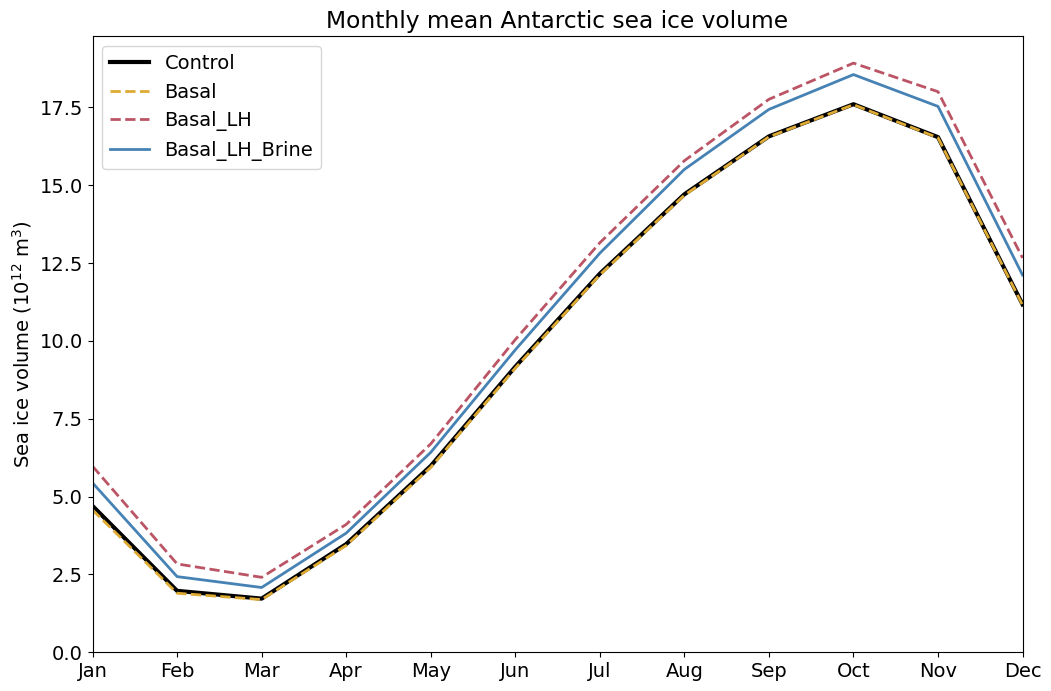

In [11]:
plt.figure(figsize=figsize)
for n, d in vol.items():
    (d/1e12).groupby('time.month').mean('time', skipna=True).plot(label=n, **styles[n])
plt.legend()
plt.gca().set_xticks(np.arange(1, 13), monthnames)
plt.xlim(xmin=1, xmax=12)
plt.ylim(ymin=0, ymax=None)
plt.title('Monthly mean Antarctic sea ice volume')
plt.xlabel('')
plt.ylabel('Sea ice volume ($10^{12}$ m$^3$)')

Text(0, 0.5, 'Sea ice volume ($10^{12}$ m$^3$)')

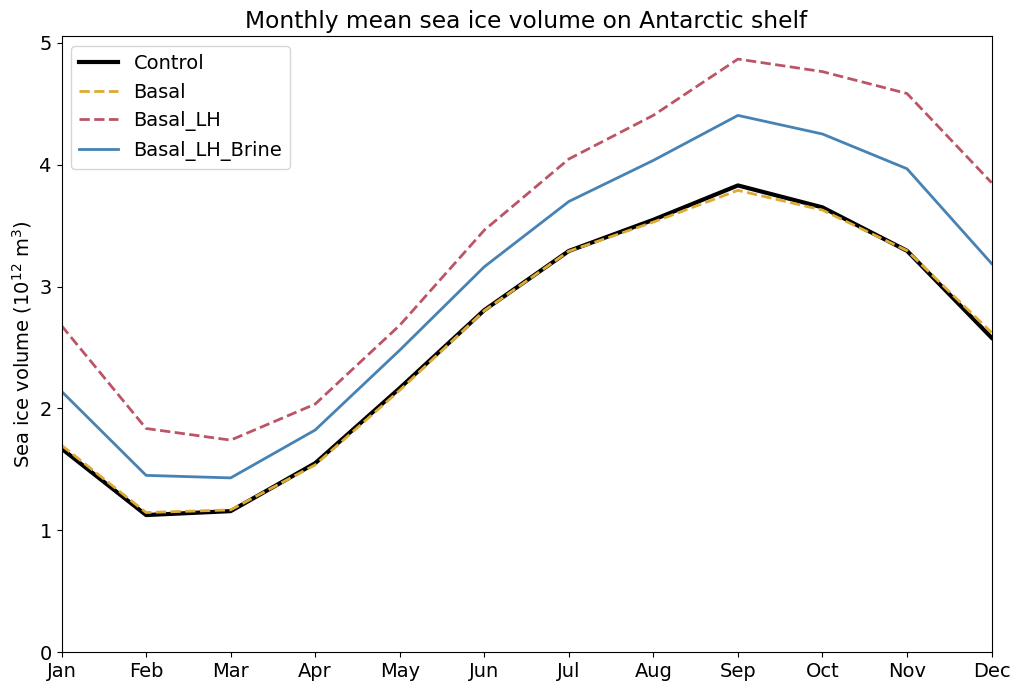

In [12]:
plt.figure(figsize=figsize)
for n, d in vol_shelf.items():
    (d/1e12).groupby('time.month').mean('time', skipna=True).plot(label=n, **styles[n])
plt.legend()
plt.gca().set_xticks(np.arange(1, 13), monthnames)
plt.xlim(xmin=1, xmax=12)
plt.ylim(ymin=0, ymax=None)
plt.title('Monthly mean sea ice volume on Antarctic shelf')
plt.xlabel('')
plt.ylabel('Sea ice volume ($10^{12}$ m$^3$)')

Text(0, 0.5, 'Sea ice volume ($10^{12}$ m$^3$)')

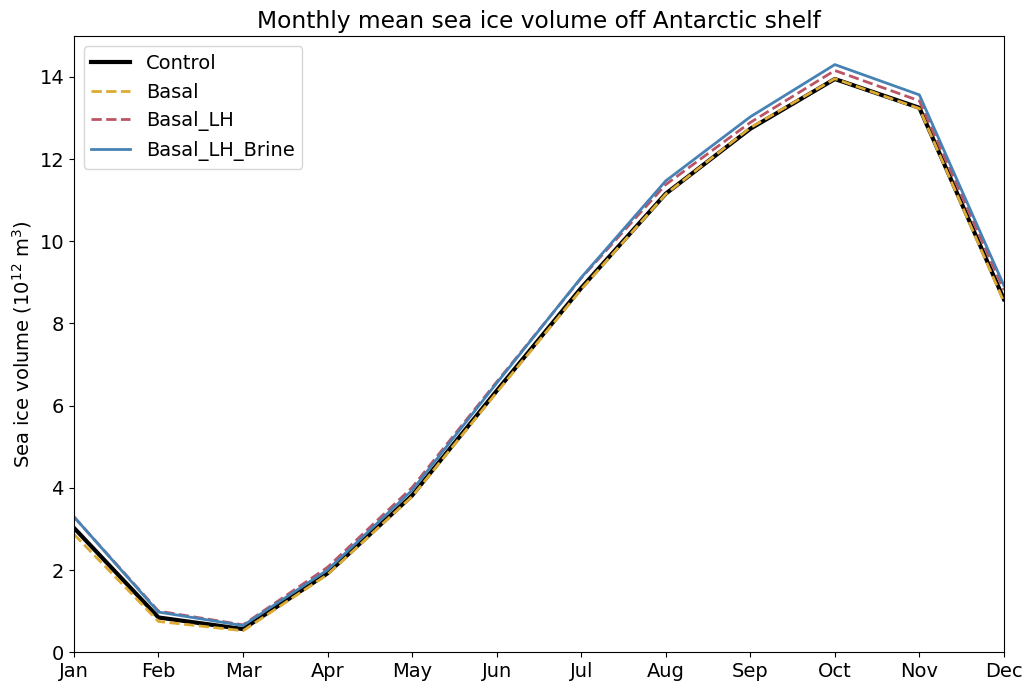

In [13]:
plt.figure(figsize=figsize)
for n, d in vol.items():
    ((d-vol_shelf[n])/1e12).groupby('time.month').mean('time', skipna=True).plot(label=n, **styles[n])
plt.legend()
plt.gca().set_xticks(np.arange(1, 13), monthnames)
plt.xlim(xmin=1, xmax=12)
plt.ylim(ymin=0, ymax=None)
plt.title('Monthly mean sea ice volume off Antarctic shelf')
plt.xlabel('')
plt.ylabel('Sea ice volume ($10^{12}$ m$^3$)')

Text(0, 0.5, 'Sea ice volume ($10^{12}$ m$^3$)')

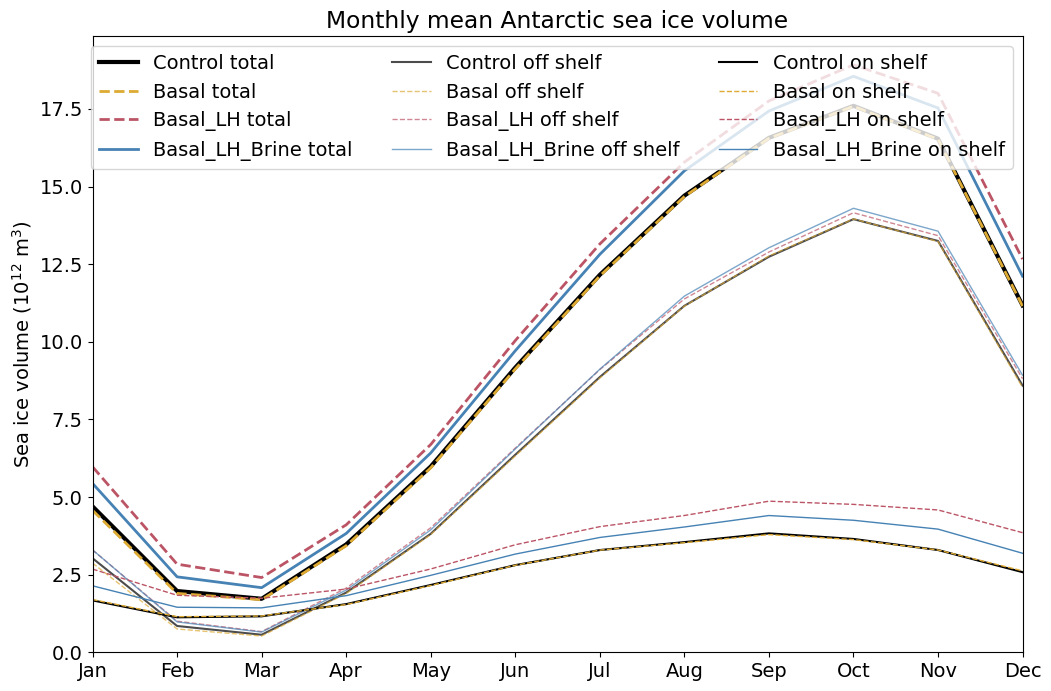

In [14]:
plt.figure(figsize=figsize)
for n, d in vol.items():
    (d/1e12).groupby('time.month').mean('time', skipna=True).plot(label=n+" total", **styles[n])
for n, d in vol.items():
    ((d-vol_shelf[n])/1e12).groupby('time.month').mean('time', skipna=True).plot(label=n+" off shelf", **styles_offshelf[n])
for n, d in vol.items():
    (vol_shelf[n]/1e12).groupby('time.month').mean('time', skipna=True).plot(label=n+" on shelf", **styles_onshelf[n])
plt.legend(ncols=3)
plt.gca().set_xticks(np.arange(1, 13), monthnames)
plt.xlim(xmin=1, xmax=12)
plt.ylim(ymin=0, ymax=None)
plt.title('Monthly mean Antarctic sea ice volume')
plt.xlabel('')
plt.ylabel('Sea ice volume ($10^{12}$ m$^3$)')

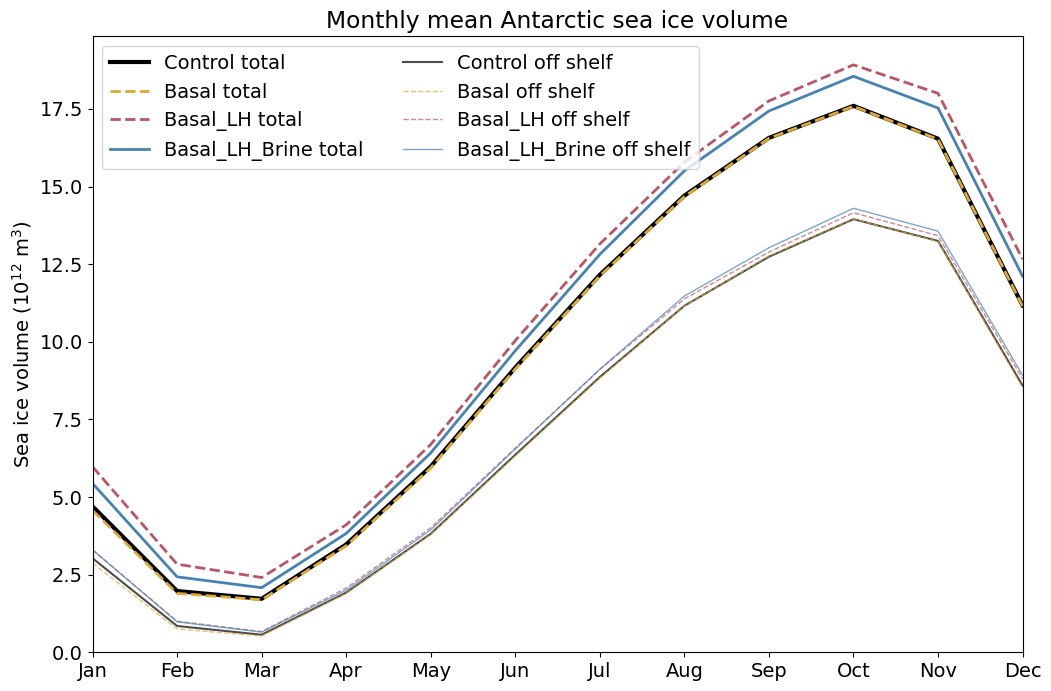

In [15]:
plt.figure(figsize=figsize)
for n, d in vol.items():
    (d/1e12).groupby('time.month').mean('time', skipna=True).plot(label=n+" total", **styles[n])
for n, d in vol.items():
    ((d-vol_shelf[n])/1e12).groupby('time.month').mean('time', skipna=True).plot(label=n+" off shelf", **styles_offshelf[n])
    # (vol_shelf[n]/1e12).groupby('time.month').mean('time', skipna=True).plot(**styles[n])
plt.legend(ncols=2)
plt.gca().set_xticks(np.arange(1, 13), monthnames)
plt.xlim(xmin=1, xmax=12)
plt.ylim(ymin=0, ymax=None)
plt.title('Monthly mean Antarctic sea ice volume')
plt.xlabel('')
plt.ylabel('Sea ice volume ($10^{12}$ m$^3$)')

plt.savefig('seaice_volume.pdf')